<a href="https://colab.research.google.com/github/Tee-Sarun/DADS-6005-Real-Time-Analytics/blob/main/ARIMA_Tutorial_(HW4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading and Visualizing the Dataset:

       Sales
Month       
1-Jan  266.0
2-Jan  145.9
3-Jan  183.1
4-Jan  119.3
5-Jan  180.3


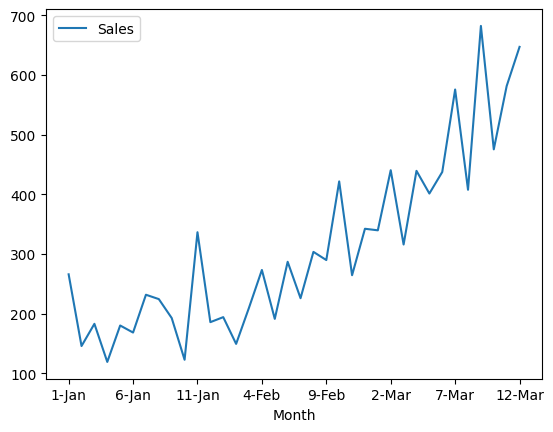

In [6]:
from pandas import read_csv
from datetime import datetime
from matplotlib import pyplot

series = read_csv('Shampoo.csv', header=0, parse_dates=[0], index_col=0, date_format='%Y-%b')
print(series.head())
series.plot()
pyplot.show()

The data is also plotted as a time series with the month along the x-axis and sales figures on the y-axis.

We can see that the Shampoo Sales dataset has a clear trend. This suggests that the time series is not stationary and will require differencing to make it stationary, at least a difference order of 1.

Pandas offers a built-in capability to plot autocorrelations. The following example showcases the autocorrelation for an extensive set of time series lags:

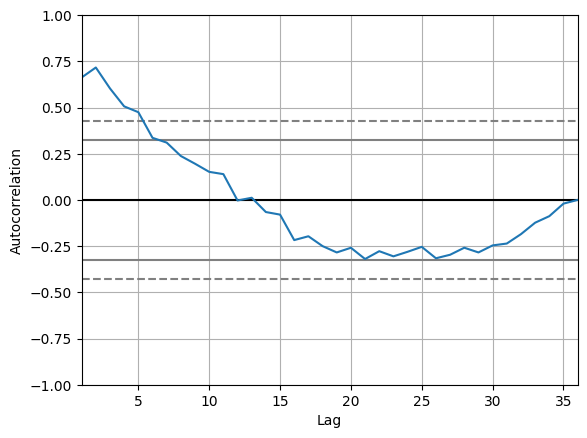

In [11]:
from pandas import read_csv
from datetime import datetime
from matplotlib import pyplot
from pandas.plotting import autocorrelation_plot

series = read_csv('Shampoo.csv', header=0, parse_dates=[0], index_col=0, date_format='%Y-%b')
autocorrelation_plot(series)
pyplot.show()

Running the example, we can see that there is a positive correlation with the first 10-to-12 lags that is perhaps significant for the first 5 lags.

This provides a hint: initiating the AR parameter of our model with a value of 5 could be a beneficial starting point.

# ARIMA with Python

The statsmodels library stands as a vital tool for those looking to harness the power of ARIMA for time series forecasting in Python.

Building an ARIMA Model: A Step-by-Step Guide:

Model Definition: Initialize the ARIMA model by invoking ARIMA() and specifying the p, d, and q parameters.
Model Training: Train the model on your dataset using the fit() method.
Making Predictions: Generate forecasts by utilizing the predict() function and designating the desired time index or indices.
Let’s start with something simple. We will fit an ARIMA model to the entire Shampoo Sales dataset and review the residual errors.

We’ll employ the ARIMA(5,1,0) configuration:

5 lags for autoregression (AR)
1st order differencing (I)
No moving average term (MA)

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -198.485
Date:                Sat, 04 Apr 2026   AIC                            408.969
Time:                        07:19:13   BIC                            418.301
Sample:                    01-31-1901   HQIC                           412.191
                         - 03-31-1901                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9014      0.247     -3.647      0.000      -1.386      -0.417
ar.L2         -0.2284      0.268     -0.851      0.395      -0.754       0.298
ar.L3          0.0747      0.291      0.256      0.7

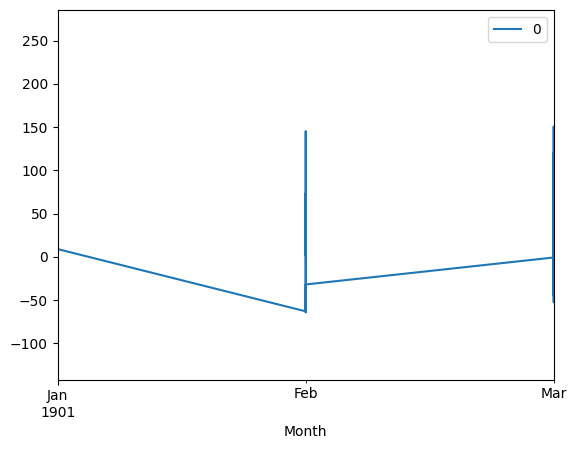

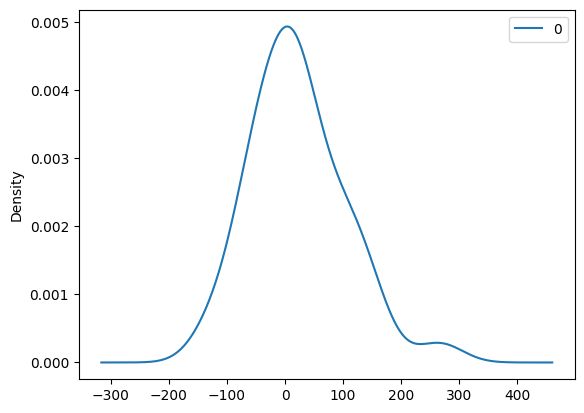

                0
count   36.000000
mean    21.936144
std     80.774430
min   -122.292030
25%    -35.040859
50%     13.147219
75%     68.848286
max    266.000000


In [17]:
# fit an ARIMA model and plot residual errors
from datetime import datetime
from pandas import read_csv
from pandas import DataFrame
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

# Custom date parser for 'X-MonthAbbr' format (e.g., '1-Jan', '10-Feb')
def parse_shampoo_date_index(date_str):
    parts = date_str.split('-')
    month_seq_num = int(parts[0])
    month_abbr = parts[1]

    # Calculate the year assuming the series starts in Jan 1901
    # e.g., months 1-12 are 1901, months 13-24 are 1902, etc.
    year = 1900 + (month_seq_num - 1) // 12 + 1

    # Construct a valid date string for strptime, e.g., '1901-Jan'
    formatted_date_str = f'{year}-{month_abbr}'
    return datetime.strptime(formatted_date_str, '%Y-%b')

# load dataset
series_raw = read_csv('Shampoo.csv', header=0, index_col=0)

# Convert the string index to DatetimeIndex using the custom parser
series_raw.index = series_raw.index.map(parse_shampoo_date_index)

series = series_raw.copy()
series.index = series.index.to_period('M')
# fit model
model = ARIMA(series, order=(5,1,0))
model_fit = model.fit()
# summary of fit model
print(model_fit.summary())
# line plot of residuals
residuals = DataFrame(model_fit.resid)
residuals.plot()
pyplot.show()
# density plot of residuals
residuals.plot(kind='kde')
pyplot.show()
# summary stats of residuals
print(residuals.describe())

Running the example prints a summary of the fit model. This summarizes the coefficient values used as well as the skill of the fit on the on the in-sample observations.

First, we get a line plot of the residual errors, suggesting that there may still be some trend information not captured by the model

Next, we get a density plot of the residual error values, suggesting the errors are Gaussian, but may not be centred on zero.

The distribution of the residual errors is displayed. The results show that indeed there is a bias in the prediction (a non-zero mean in the residuals).

Note, that although we used the entire dataset for time series analysis, ideally we would perform this analysis on just the training dataset when developing a predictive model.

Next, let’s look at how we can use the ARIMA model to make forecasts

# Rolling Forecast ARIMA Model

The ARIMA model can be used to forecast future time steps.

The ARIMA model is adept at forecasting future time points. In a rolling forecast, the model is often retrained as new data becomes available, allowing for more accurate and adaptive predictions.

We can use the predict() function on the ARIMAResults object to make predictions. It accepts the index of the time steps to make predictions as arguments. These indexes are relative to the start of the training dataset used to make predictions.

How to Forecast with ARIMA:

Use the predict() function on the ARIMAResults object. This function requires the index of the time steps for which predictions are needed.
To revert any differencing and return predictions in the original scale, set the typ argument to ‘levels’.
For a simpler one-step forecast, employ the forecast() function.
We can split the training dataset into train and test sets, use the train set to fit the model and generate a prediction for each element on the test set.

A rolling forecast is required given the dependence on observations in prior time steps for differencing and the AR model. A crude way to perform this rolling forecast is to re-create the ARIMA model after each new observation is received.

/tmp/ipykernel_20386/462817466.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('predicted=%f, expected=%f' % (yhat, obs))


predicted=343.272180, expected=342.300000
predicted=293.329674, expected=339.700000
predicted=368.668956, expected=440.400000
predicted=335.044741, expected=315.900000
predicted=363.220222, expected=439.300000
predicted=357.645324, expected=401.300000
predicted=443.047835, expected=437.400000
predicted=378.365674, expected=575.500000
predicted=459.415021, expected=407.600000
predicted=526.890876, expected=682.000000
predicted=457.231274, expected=475.300000
predicted=672.914944, expected=581.300000
predicted=531.541449, expected=646.900000
Test RMSE: 89.021


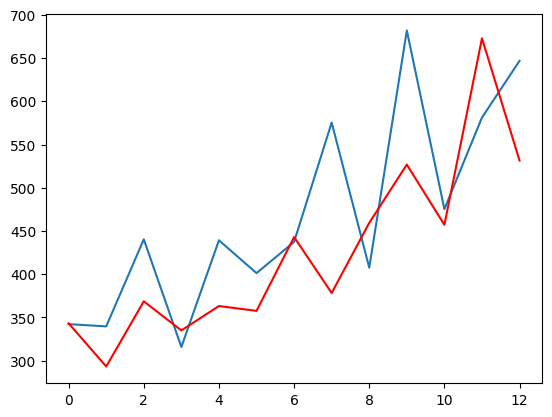

In [22]:
# evaluate an ARIMA model using a walk-forward validation
from pandas import read_csv
from datetime import datetime
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

# Custom date parser for 'X-MonthAbbr' format (e.g., '1-Jan', '10-Feb')
def parse_shampoo_date_index(date_str):
    parts = date_str.split('-')
    month_seq_num = int(parts[0])
    month_abbr = parts[1]

    # Calculate the year assuming the series starts in Jan 1901
    # e.g., months 1-12 are 1901, months 13-24 are 1902, etc.
    year = 1900 + (month_seq_num - 1) // 12 + 1

    # Construct a valid date string for strptime, e.g., '1901-Jan'
    formatted_date_str = f'{year}-{month_abbr}'
    return datetime.strptime(formatted_date_str, '%Y-%b')

# load dataset
series_raw = read_csv('Shampoo.csv', header=0, index_col=0)

# Convert the string index to DatetimeIndex using the custom parser
series_raw.index = series_raw.index.map(parse_shampoo_date_index)

series = series_raw.copy()
series.index = series.index.to_period('M')

# split into train and test sets
X = series.values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(5,1,0))
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = test[t]
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))
# evaluate forecasts
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot forecasts against actual outcomes
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

## Grid Search for Optimal ARIMA Parameters

To find the best ARIMA(p, d, q) configuration, we can perform a grid search. This involves iterating through a range of possible values for `p` (AR order), `d` (differencing order), and `q` (MA order), fitting an ARIMA model for each combination, and evaluating its performance, typically using metrics like Root Mean Squared Error (RMSE) on a test set.

The process will involve:
1.  **Defining parameter ranges**: Specify the possible values for `p`, `d`, and `q` to explore.
2.  **Iterating combinations**: Loop through all combinations of these parameters.
3.  **Fitting and evaluating**: For each combination, fit an ARIMA model using walk-forward validation and calculate the RMSE.
4.  **Selecting the best**: Keep track of the combination that yields the lowest RMSE.

We manually keep track of all observations in a list called history that is seeded with the training data and to which new observations are appended each iteration.

Putting this all together, below is an example of a rolling forecast with the ARIMA model in Python.

Running the example prints the prediction and expected value each iteration.

We can also calculate a final root mean squared error score (RMSE) for the predictions, providing a point of comparison for other ARIMA configurations.

# Configuring an ARIMA Model

ARIMA is often configured using the classical Box-Jenkins Methodology. This process employs a meticulous blend of time series analysis and diagnostics to pinpoint the most fitting parameters for the ARIMA model.

The Box-Jenkins Methodology: A Three-Step Process:

Model Identification: Begin with visual tools like plots and leverage summary statistics. These aids help recognize trends, seasonality, and autoregressive elements. The goal here is to gauge the extent of differencing required and to determine the optimal lag size.
Parameter Estimation: This step involves a fitting procedure tailored to derive the coefficients integral to the regression model.
Model Checking: Armed with plots and statistical tests delve into the residual errors. This analysis illuminates the temporal structure that the model might have missed.
The process is repeated until either a desirable level of fit is achieved on the in-sample or out-of-sample observations (e.g. training or test datasets).

The process was described in the classic 1970 textbook on the topic titled Time Series Analysis: Forecasting and Control by George Box and Gwilym Jenkins. An updated 5th edition is now available if you are interested in going deeper into this type of model and methodology.

Given that the model can be fit efficiently on modest-sized time series datasets, grid searching parameters of the model can be a valuable approach.

# Summary

Specifically, you learned:


ARIMA Model Overview: Uncovered the foundational aspects of the ARIMA model, its configuration nuances, and the key assumptions it operates on.
Quick Time Series Analysis: Explored a swift yet comprehensive analysis of time series data using the ARIMA model.
Out-of-Sample Forecasting with ARIMA: Delved into harnessing the ARIMA model for making predictions beyond the sample data.

In [23]:
# Grid search for ARIMA(p,d,q) parameters
from pandas import read_csv
from datetime import datetime
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
import warnings

# Custom date parser for 'X-MonthAbbr' format (e.g., '1-Jan', '10-Feb')
def parse_shampoo_date_index(date_str):
    parts = date_str.split('-')
    month_seq_num = int(parts[0])
    month_abbr = parts[1]

    # Calculate the year assuming the series starts in Jan 1901
    # e.g., months 1-12 are 1901, months 13-24 are 1902, etc.
    year = 1900 + (month_seq_num - 1) // 12 + 1

    # Construct a valid date string for strptime, e.g., '1901-Jan'
    formatted_date_str = f'{year}-{month_abbr}'
    return datetime.strptime(formatted_date_str, '%Y-%b')

# evaluate an ARIMA model for a given (p,d,q) order
def evaluate_arima_model(X, arima_order):
    # split into train and test sets
    size = int(len(X) * 0.66)
    train, test = X[0:size], X[size:len(X)]
    history = [x for x in train]
    predictions = list()
    for t in range(len(test)):
        model = ARIMA(history, order=arima_order)
        model_fit = model.fit()
        yhat = model_fit.forecast()[0] # Extract the scalar value
        predictions.append(yhat)
        obs = test[t]
        history.append(obs)
    # calculate out of sample error
    rmse = sqrt(mean_squared_error(test, predictions))
    return rmse

# evaluate combinations of p, d, and q values for an ARIMA model
def evaluate_models(dataset, p_values, d_values, q_values):
    dataset = dataset.astype('float32')
    best_score, best_cfg = float('inf'), None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p,d,q)
                try:
                    rmse = evaluate_arima_model(dataset, order)
                    if rmse < best_score:
                        best_score, best_cfg = rmse, order
                    print('ARIMA%s RMSE=%.3f' % (order, rmse))
                except:
                    continue
    print('Best ARIMA%s RMSE=%.3f' % (best_cfg, best_score))
    return best_cfg

# load dataset
series_raw = read_csv('Shampoo.csv', header=0, index_col=0)
series_raw.index = series_raw.index.map(parse_shampoo_date_index)
series = series_raw.copy()
series.index = series.index.to_period('M')
X = series.values

# define parameter ranges
p_values = [0, 1, 2, 4, 5, 6]
d_values = [0, 1, 2]
q_values = [0, 1, 2]

warnings.filterwarnings("ignore") # suppress warnings

best_order = evaluate_models(X, p_values, d_values, q_values)
print(f"The best ARIMA order found is: {best_order}")

ARIMA(0, 0, 0) RMSE=228.966
ARIMA(0, 0, 1) RMSE=195.596
ARIMA(0, 0, 2) RMSE=154.886
ARIMA(0, 1, 0) RMSE=133.156
ARIMA(0, 1, 1) RMSE=104.077
ARIMA(0, 1, 2) RMSE=68.344
ARIMA(0, 2, 0) RMSE=255.187
ARIMA(0, 2, 1) RMSE=134.168
ARIMA(0, 2, 2) RMSE=74.644
ARIMA(1, 0, 0) RMSE=152.028
ARIMA(1, 0, 1) RMSE=111.788
ARIMA(1, 0, 2) RMSE=77.081
ARIMA(1, 1, 0) RMSE=88.631
ARIMA(1, 1, 1) RMSE=87.942
ARIMA(1, 1, 2) RMSE=90.986
ARIMA(1, 2, 0) RMSE=134.576
ARIMA(1, 2, 1) RMSE=86.157
ARIMA(1, 2, 2) RMSE=65.511
ARIMA(2, 0, 0) RMSE=100.879
ARIMA(2, 0, 1) RMSE=98.953
ARIMA(2, 0, 2) RMSE=98.691
ARIMA(2, 1, 0) RMSE=85.063
ARIMA(2, 1, 1) RMSE=88.428
ARIMA(2, 1, 2) RMSE=83.497
ARIMA(2, 2, 0) RMSE=97.829
ARIMA(2, 2, 1) RMSE=76.847
ARIMA(2, 2, 2) RMSE=80.810
ARIMA(4, 0, 0) RMSE=100.974
ARIMA(4, 0, 1) RMSE=101.466
ARIMA(4, 0, 2) RMSE=97.884
ARIMA(4, 1, 0) RMSE=95.068
ARIMA(4, 1, 1) RMSE=84.817
ARIMA(4, 1, 2) RMSE=84.205
ARIMA(4, 2, 0) RMSE=85.397
ARIMA(4, 2, 1) RMSE=74.219
ARIMA(4, 2, 2) RMSE=70.140
ARIMA(5, 0, 0) 